#

<div style="background: linear-gradient(135deg, #0f0c29, #302b63, #24243e); border-radius: 16px; padding: 36px 40px; margin-bottom: 8px;">
  <h1 style="color: #e0aaff; font-size: 2.4em; font-weight: 800; margin: 0 0 10px 0; letter-spacing: 1px;">
    ⚡ XGBoost × CatBoost · Prediksi Pembelian Kendaraan Listrik
  </h1>
  <p style="color: #c77dff; font-size: 1.15em; margin: 0 0 18px 0; font-weight: 500;">
    Projek Sains Data · Weighted Soft-Voting Ensemble · Null Importance · Optuna · Stratified 10-Fold · Kaggle GPU T4×2
  </p>
  <hr style="border: none; border-top: 1px solid #7b2d8b; margin: 16px 0;">
  <p style="color: #9d8cff; font-size: 0.97em; margin: 0;">
    Notebook ini membangun model dari awal hingga akhir untuk memprediksi apakah seorang calon pembeli akan membeli
    kendaraan listrik (<strong>Will_Buy_EV</strong>). Fitur turunan diseleksi secara statistik dengan
    <strong>null importance</strong>, dua model gradient boosting — <strong>XGBoost</strong> dan <strong>CatBoost</strong> —
    di-tuning dengan <strong>Optuna</strong> di GPU, dilatih dengan <strong>Stratified 10-Fold</strong>, lalu digabung lewat
    <strong>weighted soft voting</strong>. Artefak akhir siap di-serve oleh <strong>FastAPI</strong>. 🚗🔋
  </p>
</div>

In [1]:
%env EV_SMOKE=1

env: EV_SMOKE=1


##
<div style="background: linear-gradient(90deg, #03071e, #370617); border-left: 4px solid #f48c06; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #ffd60a; margin: 0 0 10px 0;">Alur Kerja</h2>
  <ul style="color: #ffb703; margin: 0; padding-left: 20px;">
    <li>Setup (deteksi Kaggle &amp; GPU) → load data → pemeriksaan kualitas data → EDA</li>
    <li>Holdout 20% dikunci → feature engineering (35 kandidat, semuanya diturunkan dari 13 kolom input)</li>
    <li>Seleksi fitur: <strong>null importance</strong> (uji permutasi target) + konfirmasi 10-fold (corrected resampled t-test)</li>
    <li>Optuna untuk XGBoost &amp; CatBoost (5-fold, 2 trial paralel di 2 GPU, pruning, early stopping)</li>
    <li>Training final <strong>Stratified 10-Fold</strong> → prediksi OOF → prior correction</li>
    <li>Weighted soft voting + threshold F1-optimal, keduanya dipilih dari OOF</li>
    <li>Refit 3 seed → evaluasi holdout, bootstrap CI, analisis segmen, SHAP → simpan artefak → uji inferensi ala FastAPI</li>
  </ul>
</div>

##
<div style="background: linear-gradient(90deg, #012a4a, #013a63); border-left: 4px solid #48cae4; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #90e0ef; margin: 0 0 8px 0;">Setup &amp; Konfigurasi</h2>
  <p style="color: #ade8f4; margin: 0;">Notebook berjalan di <strong>Kaggle</strong> (GPU T4×2) maupun lokal (CPU) — path &amp; device dideteksi otomatis. Di Kaggle, repo GitHub di-clone saat runtime (butuh <strong>Internet ON</strong>) sehingga kode &amp; data identik dengan commit di <code>main</code>; hash commit dicatat di artefak. Seed 42 di semua tempat. <strong>EV_SMOKE=1</strong> menjalankan versi mini (30k baris, budget kecil) untuk uji cepat end-to-end; artefaknya ditulis ke folder sementara.</p>
</div>

In [2]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")  # tqdm (dipakai optuna) tanpa ipywidgets
warnings.filterwarnings("ignore", message=".*mismatched devices.*")  # prediksi data CPU dengan model GPU

import inspect
import json
import os
import queue
import shutil
import subprocess
import sys
import tempfile
from datetime import datetime, timezone
from pathlib import Path

import catboost
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import sklearn
import xgboost
from catboost import CatBoostClassifier, Pool
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
from scipy import stats
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, average_precision_score,
                             brier_score_loss, f1_score, precision_recall_curve, precision_score, recall_score,
                             roc_auc_score)
from sklearn.model_selection import StratifiedKFold, train_test_split
from xgboost import DMatrix, XGBClassifier

warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)
plt.rcParams["figure.dpi"] = 110

REPO_URL = "https://github.com/kevinnzzz/EV-web.git"
ON_KAGGLE = Path("/kaggle/working").exists()
if ON_KAGGLE:
    REPO_DIR, WORK_DIR = Path("/tmp/EV-web"), Path("/kaggle/working")
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=True)
else:
    REPO_DIR = WORK_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DATA_PATH = REPO_DIR / "data" / "raw" / "predicting-electric-vehicle-purchases.csv"
COMMIT = subprocess.run(["git", "-C", str(REPO_DIR), "rev-parse", "--short", "HEAD"],
                        capture_output=True, text=True).stdout.strip()
sys.path.insert(0, str(REPO_DIR / "src"))
from ev_web import model as ev

SEED = 42
SMOKE = os.environ.get("EV_SMOKE") == "1"  # uji cepat end-to-end
N_GPUS = 0
if shutil.which("nvidia-smi"):
    N_GPUS = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout.count("GPU ")
GPU_POOL = queue.Queue()  # trial Optuna paralel: tiap trial meminjam 1 GPU dari pool
for g in range(max(N_GPUS, 1)):
    GPU_POOL.put(g)
MODEL_DIR = Path(tempfile.mkdtemp()) if SMOKE else WORK_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

N_FOLDS, TUNE_FOLDS = (3, 2) if SMOKE else (10, 5)
N_TRIALS = {"xgb": 2, "cat": 2} if SMOKE else {"xgb": 300, "cat": 200}
TIMEOUT = {"xgb": 3 * 3600, "cat": 4 * 3600}  # detik; menjaga total run < 12 jam (batas sesi Kaggle)
MAX_ROUNDS, EARLY_STOP = (300, 50) if SMOKE else (20_000, 200)
N_NULL, NULL_ROUNDS = (20, 50) if SMOKE else (50, 300)  # permutasi & jumlah pohon null importance
N_SEEDS = 2 if SMOKE else 3  # seed averaging model final
N_BOOT = 200 if SMOKE else 2000  # resample bootstrap

print(f"python {sys.version.split()[0]} | xgboost {xgboost.__version__} | catboost {catboost.__version__} | "
      f"optuna {optuna.__version__} | sklearn {sklearn.__version__} | pandas {pd.__version__}")
print(f"Kaggle={ON_KAGGLE} | commit {COMMIT} | GPU={N_GPUS} | SMOKE={SMOKE} | fold final={N_FOLDS}, tuning={TUNE_FOLDS} | "
      f"trials={N_TRIALS} | artefak -> {MODEL_DIR}")

Cloning into '/tmp/EV-web'...


python 3.12.13 | xgboost 3.2.0 | catboost 1.2.10 | optuna 4.9.0 | sklearn 1.6.1 | pandas 2.3.3
Kaggle=True | commit 31189eb | GPU=2 | SMOKE=True | fold final=3, tuning=2 | trials={'xgb': 2, 'cat': 2} | artefak -> /tmp/tmp2x10so_a


##
<div style="background: linear-gradient(90deg, #1b1b2f, #2d2b55); border-left: 4px solid #a855f7; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #d8b4fe; margin: 0 0 8px 0;">Load Data</h2>
  <p style="color: #c4b5fd; margin: 0;">668,665 baris × 15 kolom. Kolom <code>id</code> dibuang karena hanya penomoran. Target <strong>Will_Buy_EV</strong> dipetakan ke 1 (Yes) / 0 (No).</p>
</div>

In [3]:
df = pd.read_csv(DATA_PATH).drop(columns="id")
if SMOKE:
    df = df.sample(30_000, random_state=SEED).reset_index(drop=True)
y = (df[ev.TARGET] == "Yes").astype(int)
print(df.shape)
df.head()

(30000, 14)


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,59,86435.0,5.0,2,7,3,4.0,Female,Suburban,SUV,Yes,No,Low,No
1,55,75534.0,17.8,3,2,1,4.0,Male,Rural,Sedan,Yes,Yes,Low,No
2,50,30000.0,37.7,1,14,3,2.0,Female,Urban,SUV,No,Yes,Medium,No
3,64,63750.0,58.9,1,6,16,1.0,Male,Urban,SUV,No,No,Low,No
4,64,92704.0,22.3,3,7,11,4.0,Female,Urban,SUV,No,Yes,Low,No


##
<div style="background: linear-gradient(90deg, #0d1b2a, #1b263b); border-left: 4px solid #00b4d8; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #90e0ef; margin: 0 0 8px 0;">Pemeriksaan Kualitas Data</h2>
  <p style="color: #ade8f4; margin: 0;">Tipe data, missing value, duplikat, distribusi kategori, statistik deskriptif, dan indikasi <em>clipping</em> di batas bawah fitur numerik.</p>
</div>

In [4]:
df.info()
print(f"\nMissing value : {df.isna().sum().sum()}")
print(f"Baris duplikat: {df.duplicated().sum()}")
print(f"Income tepat 30,000 : {(df['Annual_Income_USD'] == 30_000).mean():.2%}")
print(f"Commute tepat 5 km  : {(df['Daily_Commute_km'] == 5).mean():.2%}\n")
for c in df.select_dtypes(exclude="number"):
    print(f"{c}: {df[c].value_counts().to_dict()}")
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          30000 non-null  int64  
 1   Annual_Income_USD            30000 non-null  float64
 2   Daily_Commute_km             30000 non-null  float64
 3   Number_of_Cars_Owned         30000 non-null  int64  
 4   Charging_Stations_Near_Home  30000 non-null  int64  
 5   Charging_Stations_Near_Work  30000 non-null  int64  
 6   Environmental_Concern_Level  30000 non-null  float64
 7   Gender                       30000 non-null  object 
 8   City_Type                    30000 non-null  object 
 9   Current_Car_Type             30000 non-null  object 
 10  Home_Charging_Possible       30000 non-null  object 
 11  Subsidy_Available            30000 non-null  object 
 12  Range_Anxiety_Level          30000 non-null  object 
 13  Will_Buy_EV     

,count,mean,std,min,25%,50%,75%,max
Age,30000.0,47.017233,12.872350,25.0,36.0,47.0,58.00,69.0
Annual_Income_USD,30000.0,84721.981100,28664.463027,30000.0,66948.5,84832.0,102629.75,179948.0
Daily_Commute_km,30000.0,31.945790,18.756384,5.0,16.6,33.2,47.10,98.3
Number_of_Cars_Owned,30000.0,1.707867,0.727468,1.0,1.0,2.0,2.00,4.0
Charging_Stations_Near_Home,30000.0,4.955867,3.925264,0.0,2.0,4.0,7.00,14.0
Charging_Stations_Near_Work,30000.0,7.163033,5.180362,0.0,3.0,6.0,10.00,19.0
Environmental_Concern_Level,30000.0,2.943533,1.429503,1.0,2.0,3.0,4.00,5.0


##
<div style="background: linear-gradient(90deg, #1a1a2e, #16213e); border-left: 4px solid #e94560; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #f5a623; margin: 0 0 8px 0;">EDA · Target &amp; Imbalance</h2>
  <p style="color: #ffd6a5; margin: 0;">Seberapa timpang kelas target, dan kenapa akurasi saja menyesatkan.</p>
</div>

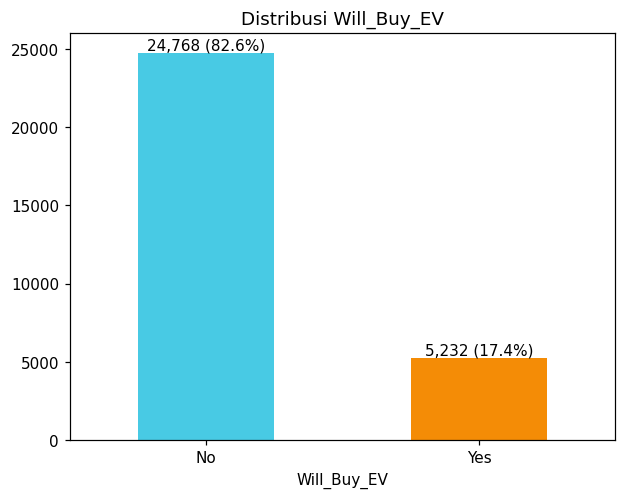

Rasio neg:pos = 4.73 | akurasi model 'selalu No' = 82.6%


In [5]:
counts = df[ev.TARGET].value_counts()
ax = counts.plot.bar(color=["#48cae4", "#f48c06"], rot=0, title="Distribusi Will_Buy_EV")
ax.bar_label(ax.containers[0], labels=[f"{n:,} ({n / len(df):.1%})" for n in counts])
plt.show()
print(f"Rasio neg:pos = {counts['No'] / counts['Yes']:.2f} | akurasi model 'selalu No' = {counts['No'] / len(df):.1%}")

##
<div style="background: linear-gradient(90deg, #2d0036, #4a0060); border-left: 4px solid #bf5af2; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #e0aaff; margin: 0 0 8px 0;">EDA · Fitur Numerik vs Target</h2>
  <p style="color: #c77dff; margin: 0;">Distribusi (density) tiap fitur numerik, dipisah per kelas target.</p>
</div>

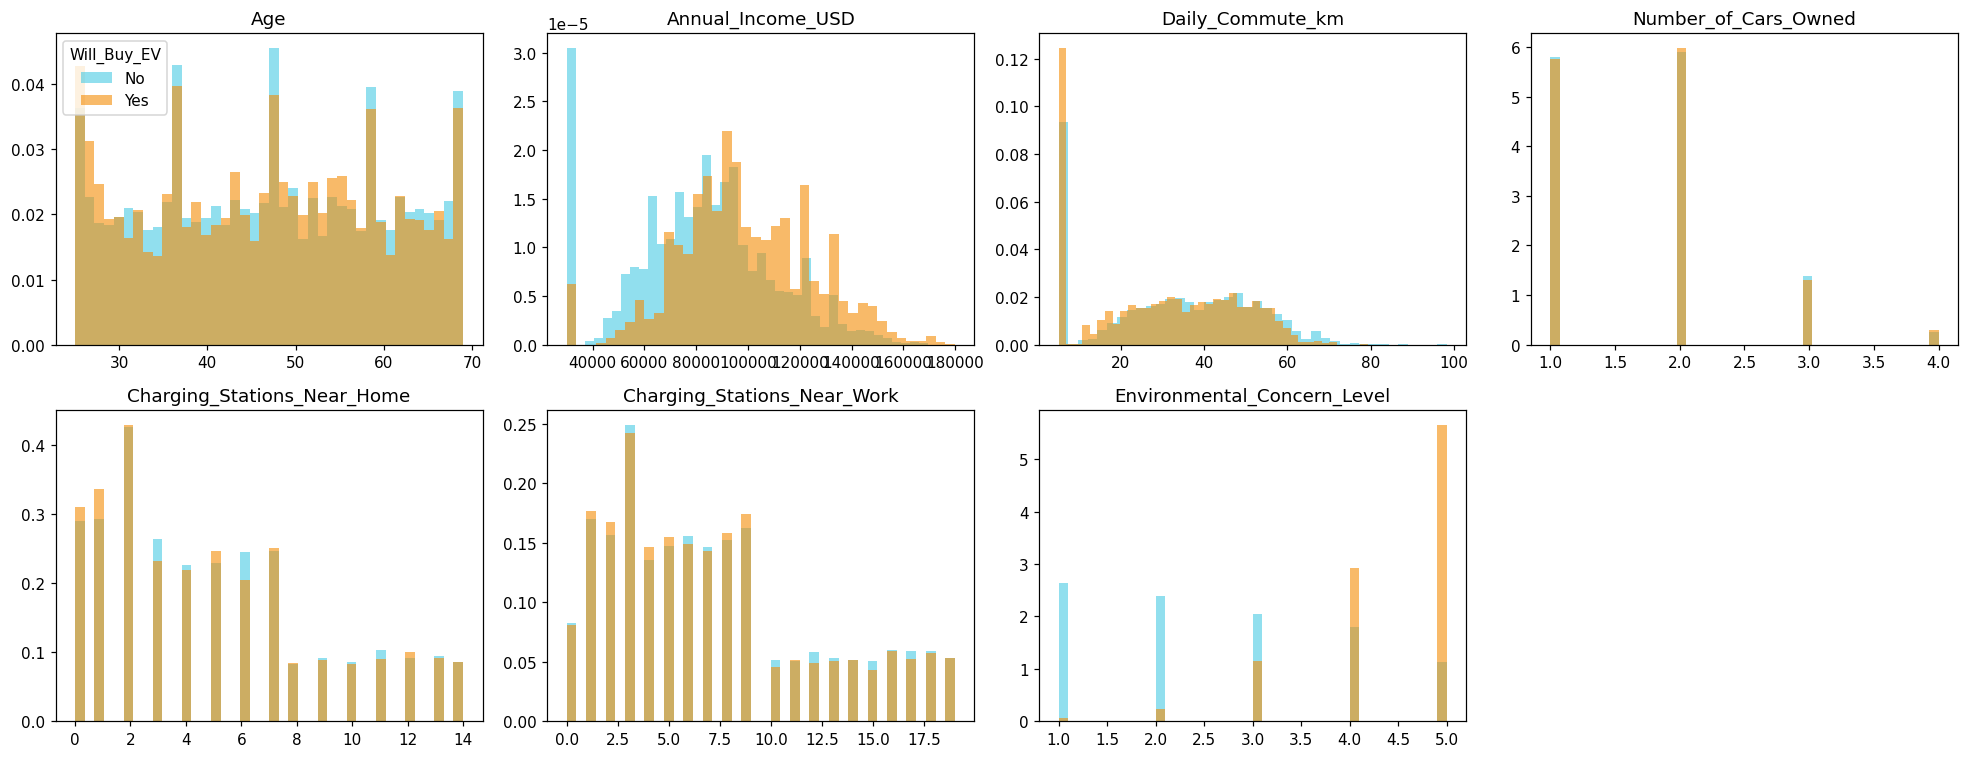

Will_Buy_EV,No,Yes
Age,47.10,46.62
Annual_Income_USD,81714.54,98959.04
Daily_Commute_km,32.36,30.00
Number_of_Cars_Owned,1.71,1.71
Charging_Stations_Near_Home,4.98,4.86
Charging_Stations_Near_Work,7.19,7.05
Environmental_Concern_Level,2.64,4.39


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.flat, ev.NUMERIC):
    for label, color in [("No", "#48cae4"), ("Yes", "#f48c06")]:
        ax.hist(df.loc[df[ev.TARGET] == label, c], bins=40, density=True, alpha=0.6, color=color, label=label)
    ax.set_title(c)
axes.flat[0].legend(title=ev.TARGET)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()
df.groupby(ev.TARGET)[ev.NUMERIC].mean().T.round(2)

##
<div style="background: linear-gradient(90deg, #10002b, #240046); border-left: 4px solid #c77dff; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #e0aaff; margin: 0 0 8px 0;">EDA · Fitur Kategorikal — Tingkat Pembelian EV</h2>
  <p style="color: #9d8cff; margin: 0;">Proporsi <strong>Yes</strong> per kategori; garis putus-putus = rata-rata global.</p>
</div>

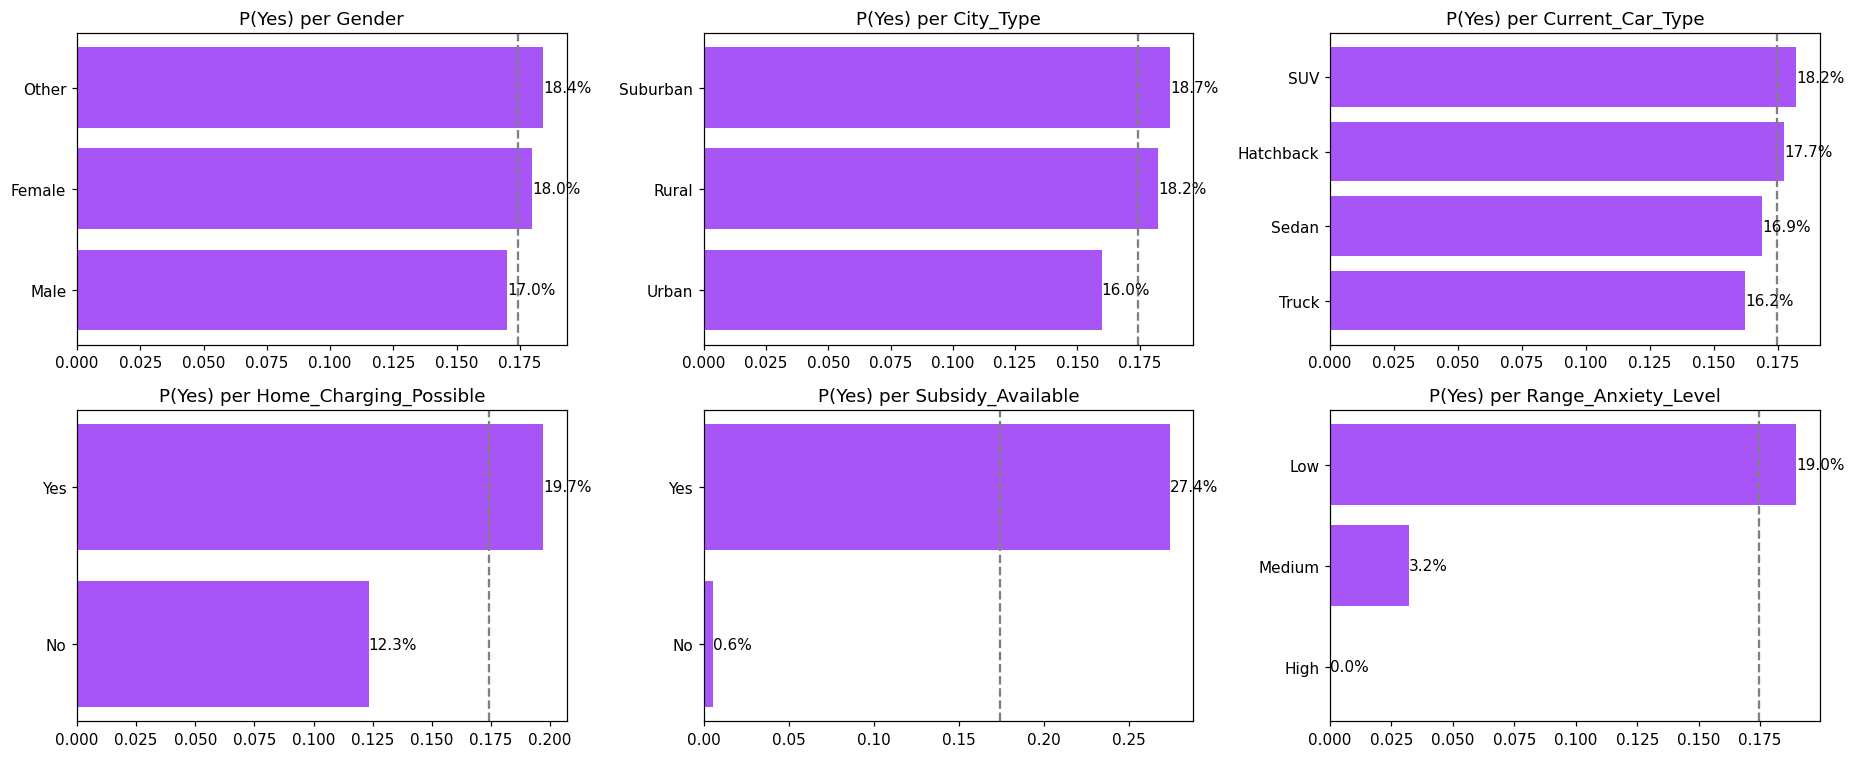

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(17, 7))
for ax, c in zip(axes.flat, list(ev.CATEGORIES) + list(ev.TO_INT)):
    rate = y.groupby(df[c]).mean().sort_values()
    ax.barh(rate.index, rate, color="#a855f7")
    ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate])
    ax.axvline(y.mean(), ls="--", c="gray")
    ax.set_title(f"P(Yes) per {c}")
plt.tight_layout()
plt.show()

##
<div style="background: linear-gradient(90deg, #03071e, #370617); border-left: 4px solid #f48c06; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #ffd60a; margin: 0 0 8px 0;">EDA · Korelasi Spearman</h2>
  <p style="color: #ffb703; margin: 0;">13 fitur asli (numerik + biner + ordinal setelah encoding) terhadap target. Spearman berbasis ranking — tahan terhadap outlier &amp; hubungan monoton non-linear.</p>
</div>

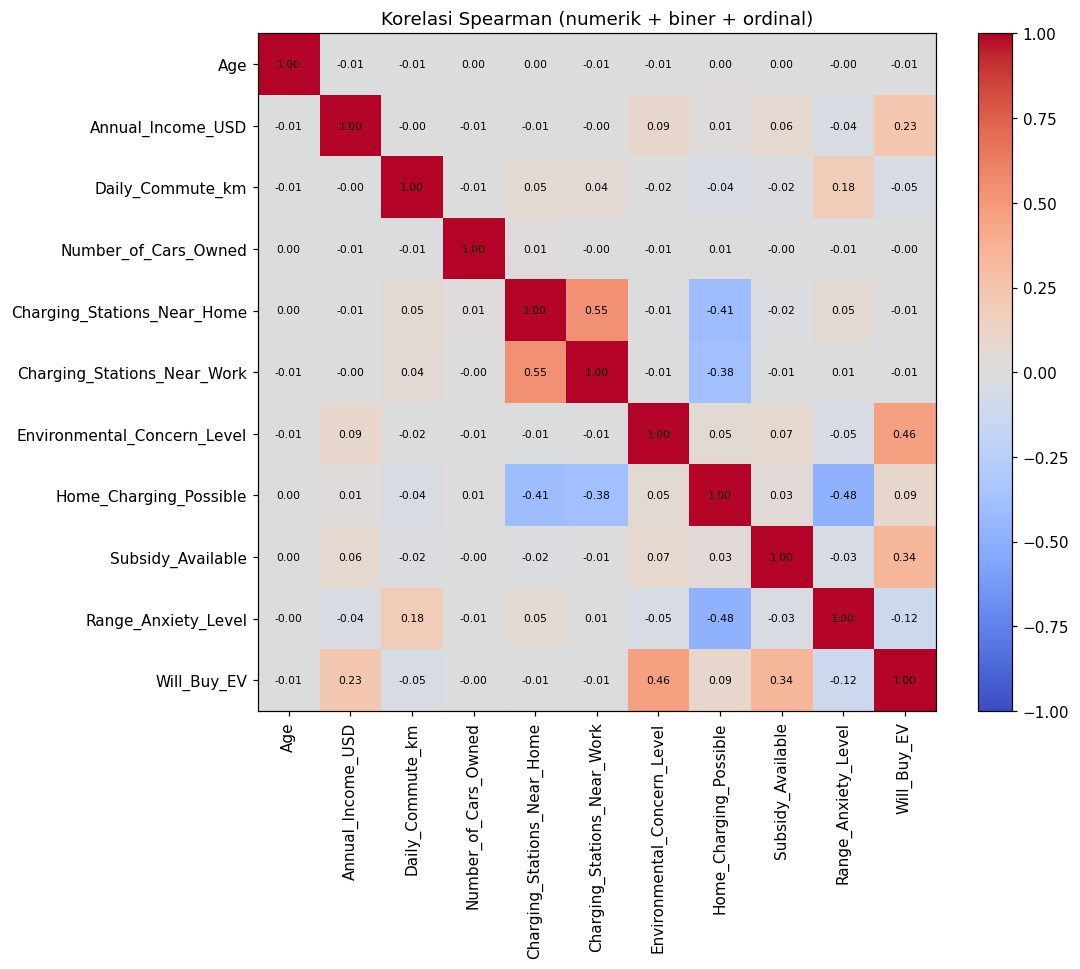

In [8]:
corr = ev.prepare(df, {})[ev.FEATURES].select_dtypes("number").assign(**{ev.TARGET: y}).corr("spearman")
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im)
ax.set_title("Korelasi Spearman (numerik + biner + ordinal)")
plt.show()

##
<div style="background: linear-gradient(90deg, #012a4a, #013a63); border-left: 4px solid #48cae4; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #90e0ef; margin: 0 0 10px 0;">Insight EDA</h2>
  <ul style="color: #ade8f4; margin: 0; padding-left: 20px;">
    <li><strong>Imbalance</strong>: hanya 17.5% Yes (rasio 4.73 : 1). Model yang selalu menebak No sudah 82.5% akurat → akurasi menyesatkan; metrik utama <strong>ROC-AUC</strong>, didukung PR-AUC &amp; F1.</li>
    <li><strong>Subsidy_Available</strong> fitur paling tajam: tanpa subsidi hanya 0.6% yang membeli, dengan subsidi 27.5%.</li>
    <li><strong>Environmental_Concern_Level</strong> berkorelasi paling kuat (Spearman 0.46): rata-rata 4.38 (Yes) vs 2.63 (No). <strong>Annual_Income_USD</strong> menyusul (0.22; rata-rata 98.8k vs 81.8k USD).</li>
    <li><strong>Range_Anxiety_Level</strong> menekan minat: Low 18.9% → Medium 4.2% → High 0.1%.</li>
    <li>Home charging menaikkan peluang (19.6% vs 12.7%); Rural (19.3%) justru sedikit di atas Urban (16.1%).</li>
    <li>Gender, Age, jumlah mobil, dan jumlah stasiun charging hampir tidak berkorelasi secara individual — keputusan memakai atau membuangnya diserahkan ke seleksi fitur statistik (null importance).</li>
    <li>Tanpa missing value &amp; duplikat. 9.2% income tepat 30,000 dan 21.6% commute tepat 5 km (batas bawah / clipping) — dijadikan kandidat fitur penanda (flag).</li>
  </ul>
</div>

##
<div style="background: linear-gradient(90deg, #1b1b2f, #2d2b55); border-left: 4px solid #a855f7; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #d8b4fe; margin: 0 0 10px 0;">Split Holdout &amp; Skema Validasi</h2>
  <ul style="color: #c4b5fd; margin: 0; padding-left: 20px;">
    <li><strong>Holdout 20% stratified dikunci lebih dulu</strong> — dipakai sekali di evaluasi akhir. Tabel frekuensi (frequency encoding) dihitung dari 80% train saja agar holdout benar-benar tak terlihat.</li>
    <li>80% train: StratifiedKFold 5 untuk tuning, StratifiedKFold 10 untuk seleksi fitur &amp; training final.</li>
    <li>Satu fungsi <strong>ev_web.model.prepare()</strong> dipakai notebook <em>dan</em> FastAPI → tidak ada training/serving skew. Nilai kategori tak dikenal → <code>ValueError</code>. Tanpa scaling — tree model invarian terhadap skala.</li>
  </ul>
</div>

In [9]:
idx_train, idx_test = train_test_split(df.index, test_size=0.2, stratify=y, random_state=SEED)
FREQ = ev.freq_maps(df.loc[idx_train])  # frekuensi dari train saja
X = ev.prepare(df, FREQ)
X_train, X_test, y_train, y_test = X.loc[idx_train], X.loc[idx_test], y.loc[idx_train], y.loc[idx_test]
folds = list(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(X_train, y_train))
tune_folds = list(StratifiedKFold(TUNE_FOLDS, shuffle=True, random_state=SEED).split(X_train, y_train))
POS_WEIGHT = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"train {X_train.shape} | holdout {X_test.shape} | Yes train {y_train.mean():.2%}, "
      f"holdout {y_test.mean():.2%} | neg:pos {POS_WEIGHT:.2f}")
print(f"Kandidat fitur: 13 asli + " + ", ".join(f"{g} {len(c)}" for g, c in ev.FE_GROUPS.items()))

train (24000, 35) | holdout (6000, 35) | Yes train 17.44%, holdout 17.43% | neg:pos 4.73
Kandidat fitur: 13 asli + domain 7, clip 2, freq 7, num_cat 6


##
<div style="background: linear-gradient(90deg, #0d1b2a, #1b263b); border-left: 4px solid #00b4d8; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #90e0ef; margin: 0 0 10px 0;">Feature Engineering</h2>
  <p style="color: #ade8f4; margin: 0 0 8px 0;">Semua fitur turunan dihitung di dalam <code>prepare()</code> dari 13 kolom yang sama dengan dataset — user/web tetap hanya mengisi kolom asli.</p>
  <ul style="color: #ade8f4; margin: 0; padding-left: 20px;">
    <li><strong>Domain</strong>: Total_Charging_Stations (akses infrastruktur), Income_per_Car (daya beli per kendaraan), Concern_x_Subsidy &amp; Income_x_Concern (interaksi sinyal terkuat EDA), Anxiety_x_Commute (tekanan jarak tempuh), Commute_per_Station (jarak vs infrastruktur), Charging_Access (skor akses charging 0–3).</li>
    <li><strong>Flag clipping</strong>: Income_Clipped (≤ 30,000) &amp; Commute_Clipped (≤ 5 km) — penanda nilai yang terpotong di batas bawah.</li>
    <li><strong>Frequency encoding</strong>: <code>&lt;numerik&gt;_freq</code> = frekuensi nilai di data train (tanpa target → tanpa leakage). Tabelnya disimpan untuk serving; nilai baru → 0.</li>
    <li><strong>Numerik → kategori</strong> (khusus CatBoost): <code>&lt;numerik&gt;_cat</code> salinan string agar CatBoost mempelajari efek per-nilai lewat target statistics — trik umum pada data sintetis Kaggle Playground.</li>
  </ul>
</div>

In [10]:
print(inspect.getsource(ev.prepare))
fe_num = ev.FE_GROUPS["domain"] + ev.FE_GROUPS["clip"] + ev.FE_GROUPS["freq"]
X_train[fe_num].corrwith(y_train, method="spearman").sort_values(key=abs, ascending=False).to_frame("Spearman vs target").round(3).T

def prepare(df: pd.DataFrame, freq: dict) -> pd.DataFrame:
    """13 kolom mentah (CSV / payload API) -> semua fitur kandidat; tiap model memakai subsetnya sendiri."""
    X = df[FEATURES].copy()
    for col, mapping in TO_INT.items():
        X[col] = X[col].map(mapping)
    for col, cats in CATEGORIES.items():
        X[col] = pd.Categorical(X[col], categories=cats)
    bad = X.columns[X.isna().any()].tolist()
    if bad:
        raise ValueError(f"Nilai kosong/tidak dikenal di kolom: {bad}")

    stations = X["Charging_Stations_Near_Home"] + X["Charging_Stations_Near_Work"]
    X["Total_Charging_Stations"] = stations
    X["Income_per_Car"] = X["Annual_Income_USD"] / X["Number_of_Cars_Owned"]
    X["Concern_x_Subsidy"] = X["Environmental_Concern_Level"] * X["Subsidy_Available"]
    X["Income_x_Concern"] = X["Annual_Income_USD"] * X["Environmental_Concern_Level"]
    X["Anxiety_x_Commute"] = (X["Range_Anxiety_Level"] + 1) * X["Daily_Commute_km"]
    X["Commute_per_Station"] = X["Dail

,Concern_x_Subsidy,Income_x_Concern,Environmental_Concern_Level_freq,Income_per_Car,Income_Clipped,Annual_Income_USD_freq,Charging_Access,Anxiety_x_Commute,Commute_per_Station,Commute_Clipped,Total_Charging_Stations,Charging_Stations_Near_Work_freq,Daily_Commute_km_freq,Age_freq,Charging_Stations_Near_Home_freq,Number_of_Cars_Owned_freq
Spearman vs target,0.564,0.479,-0.268,0.142,-0.108,-0.096,0.075,-0.074,-0.024,0.014,-0.006,0.006,0.006,0.005,0.003,0.0


##
<div style="background: linear-gradient(90deg, #1a1a2e, #16213e); border-left: 4px solid #e94560; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #f5a623; margin: 0 0 10px 0;">Strategi Menangani Imbalance</h2>
  <ul style="color: #ffd6a5; margin: 0; padding-left: 20px;">
    <li><strong>Stratified split</strong> di semua level (holdout, 5-fold, 10-fold) → setiap fold memuat ±17.5% Yes.</li>
    <li><strong>Cost-sensitive learning saat training</strong>: bobot kelas positif dicari Optuna — <code>scale_pos_weight</code> ∈ [1, 4.73] (XGBoost) dan <code>auto_class_weights</code> ∈ {None, SqrtBalanced, Balanced} (CatBoost). Data yang memutuskan seberapa besar bobotnya.</li>
    <li><strong>Threshold F1-optimal</strong> dipilih dari prediksi OOF, menggantikan 0.5.</li>
    <li><strong>Prior correction</strong>: model berbobot kelas positif <em>s</em> memprediksi odds <em>s</em> kali lipat. Probabilitas dikembalikan ke skala asli dengan <code>p' = p / (p + s·(1 − p))</code> sebelum blending — AUC tidak berubah (transformasi monoton), tetapi probabilitas yang tampil di web menjadi terkalibrasi.</li>
    <li><strong>10 fold</strong>: tiap model belajar dari 90% data train dan estimasi OOF lebih stabil. K-fold sendiri tidak mengubah distribusi kelas — yang menangani imbalance adalah stratifikasi + class weight + threshold.</li>
    <li><strong>SMOTE tidak dipakai</strong>: ±94k sampel positif di data train sudah cukup, sampel sintetis mahal dibuat di ratusan ribu baris, merusak kalibrasi probabilitas, dan umumnya tidak menaikkan AUC gradient boosting.</li>
  </ul>
</div>

##
<div style="background: linear-gradient(90deg, #2d0036, #4a0060); border-left: 4px solid #bf5af2; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #e0aaff; margin: 0 0 8px 0;">Helper Model &amp; Cross-Validation</h2>
  <p style="color: #c77dff; margin: 0;"><strong>make_model()</strong> membuat XGBoost/CatBoost di GPU (bila ada) atau CPU. <strong>cv_fit()</strong> dipakai seleksi fitur, tuning, dan training final: early stopping per fold, prediksi OOF, AUC per fold, dan pelaporan ke pruner Optuna. <strong>tune()</strong> menjalankan trial paralel sebanyak GPU; study tersimpan di SQLite.</p>
</div>

In [11]:
XGB_BASE = dict(tree_method="hist", enable_categorical=True, eval_metric="auc", n_jobs=-1)
CAT_BASE = dict(bootstrap_type="Bernoulli", border_count=254, thread_count=-1, allow_writing_files=False,
                eval_metric="Logloss")  # early stopping: AUC metrik termahal & wajib dihitung tiap iterasi
# border_count 254 = default CPU (default GPU 128) agar hasil CPU/GPU sebanding
# model default untuk seleksi fitur; subsampling menyebar importance antar fitur yang saling berkorelasi
DEFAULT = {"xgb": dict(learning_rate=0.1, max_depth=6, subsample=0.8, colsample_bytree=0.5),
           "cat": dict(learning_rate=0.1, depth=6)}
CANDIDATES = {"xgb": ev.FEATURES + ev.FE_GROUPS["domain"] + ev.FE_GROUPS["clip"] + ev.FE_GROUPS["freq"],
              "cat": ev.FEATURES + [c for group in ev.FE_GROUPS.values() for c in group]}  # num_cat khusus CatBoost


def cat_cols(feats):
    return [c for c in feats if c in ev.CATEGORIES or c.endswith("_cat")]


def make_model(name, params, feats, n=MAX_ROUNDS, early_stop=True, gpu=0, seed=SEED):
    es = EARLY_STOP if early_stop else None
    if name == "xgb":
        return XGBClassifier(**XGB_BASE, **params, n_estimators=n, early_stopping_rounds=es, random_state=seed,
                             device=f"cuda:{gpu}" if N_GPUS else "cpu")
    gpu_args = dict(task_type="GPU", devices=str(gpu)) if N_GPUS else {}
    return CatBoostClassifier(**CAT_BASE, **params, **gpu_args, iterations=n, early_stopping_rounds=es,
                              random_seed=seed, cat_features=cat_cols(feats))


def cv_fit(name, params, feats, folds, trial=None, gpu=0):
    """1 model per fold (early stopping di fold validasi) -> OOF proba, AUC per fold, best iteration per fold."""
    Xf = X_train[feats]
    oof, aucs, iters = np.zeros(len(y_train)), [], []
    for k, (tr, va) in enumerate(folds):
        m = make_model(name, params, feats, gpu=gpu)
        m.fit(Xf.iloc[tr], y_train.iloc[tr], eval_set=[(Xf.iloc[va], y_train.iloc[va])], verbose=False)
        oof[va] = m.predict_proba(Xf.iloc[va])[:, 1]
        aucs.append(roc_auc_score(y_train.iloc[va], oof[va]))
        iters.append(m.get_best_iteration() if name == "cat" else m.best_iteration)
        if trial is not None:  # Optuna: laporkan AUC sementara, pangkas trial yang tertinggal dari median
            trial.report(float(np.mean(aucs)), k)
            if trial.should_prune():
                raise optuna.TrialPruned()
    return oof, aucs, iters


def tune(name, suggest):
    """Study di SQLite (re-run melanjutkan trial); trial paralel sebanyak GPU, tiap trial meminjam 1 GPU."""
    def objective(trial):
        params = suggest(trial)
        gpu = GPU_POOL.get()
        try:
            return float(np.mean(cv_fit(name, params, FEATS[name], tune_folds, trial, gpu)[1]))
        finally:
            GPU_POOL.put(gpu)

    study = optuna.create_study(
        study_name=name, direction="maximize", load_if_exists=True,
        storage=optuna.storages.RDBStorage(f"sqlite:///{(MODEL_DIR / 'optuna.db').as_posix()}",
                                           engine_kwargs={"connect_args": {"timeout": 60}}),
        sampler=optuna.samplers.TPESampler(seed=SEED, constant_liar=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
    )
    done = len(study.get_trials(states=(optuna.trial.TrialState.COMPLETE, optuna.trial.TrialState.PRUNED)))
    if done < N_TRIALS[name]:
        study.optimize(objective, n_trials=N_TRIALS[name] - done, timeout=TIMEOUT[name], n_jobs=max(N_GPUS, 1))
    print(f"[{name}] {len(study.trials)} trial | CV AUC terbaik {study.best_value:.5f}\n{study.best_params}")
    return study

##
<div style="background: linear-gradient(90deg, #10002b, #240046); border-left: 4px solid #c77dff; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #e0aaff; margin: 0 0 10px 0;">Seleksi Fitur · Null Importance (Uji Permutasi Target)</h2>
  <ul style="color: #9d8cff; margin: 0; padding-left: 20px;">
    <li>Importance berbasis split bias ke fitur berkardinalitas tinggi (income, frequency encoding) — fitur acak pun bisa terlihat penting.</li>
    <li>Model dilatih 1× dengan target asli dan 50× dengan target diacak → distribusi null = importance yang muncul murni karena kebetulan.</li>
    <li>p-value empiris = (1 + #null ≥ asli) / (1 + N). Fitur dipertahankan bila <strong>p &lt; 0.05</strong> — berlaku untuk semua kandidat, termasuk 13 fitur asli.</li>
    <li>Parameter &amp; jumlah pohon dibuat tetap (tanpa early stopping) agar importance asli vs null sebanding; XGBoost memakai row/feature subsampling (seperti metode aslinya) agar importance tersebar ke fitur yang berkorelasi.</li>
    <li>Fitur yang informasinya sudah terkandung di fitur lain bisa gugur — mis. <code>Concern_x_Subsidy = 0</code> ⇔ tanpa subsidi, sehingga gain <code>Subsidy_Available</code> terserap. Ini redundansi, bukan kehilangan informasi; konfirmasi 10-fold di bawah memastikan AUC tidak turun.</li>
  </ul>
</div>

In [12]:
def importances(name, y_fit):
    """Importance tiap kandidat fitur dari 1 model berparameter & berjumlah pohon tetap."""
    feats = CANDIDATES[name]
    m = make_model(name, DEFAULT[name], feats, n=NULL_ROUNDS, early_stop=False)
    m.fit(X_train[feats], y_fit, verbose=False)
    if name == "xgb":
        gain = m.get_booster().get_score(importance_type="total_gain")
        return pd.Series(gain, dtype=float).reindex(feats, fill_value=0.0)
    return pd.Series(m.get_feature_importance(), index=feats)


def null_importance(name):
    rng = np.random.default_rng(SEED)
    actual = importances(name, y_train)
    null = pd.DataFrame([importances(name, pd.Series(rng.permutation(y_train.to_numpy()), index=y_train.index))
                         for _ in range(N_NULL)])
    p = (1 + (null >= actual).sum()) / (1 + N_NULL)
    return pd.DataFrame({"importance": actual, "null_mean": null.mean(), "null_p95": null.quantile(0.95),
                         "p_value": p, "keep": p < 0.05}).sort_values("importance", ascending=False)


ni = {name: null_importance(name) for name in ("xgb", "cat")}
FEATS = {name: t.index[t["keep"]].tolist() for name, t in ni.items()}
for name, t in ni.items():
    print(f"[{name}] {t['keep'].sum()}/{len(t)} fitur lolos (p < 0.05) | dibuang: {t.index[~t['keep']].tolist()}")
display(ni["xgb"].round(4), ni["cat"].round(4))

[xgb] 11/29 fitur lolos (p < 0.05) | dibuang: ['Income_per_Car', 'Daily_Commute_km', 'Annual_Income_USD_freq', 'Age', 'Commute_per_Station', 'Age_freq', 'Daily_Commute_km_freq', 'Total_Charging_Stations', 'Charging_Stations_Near_Work_freq', 'Charging_Stations_Near_Work', 'Charging_Stations_Near_Home', 'Charging_Stations_Near_Home_freq', 'Current_Car_Type', 'Charging_Access', 'Number_of_Cars_Owned_freq', 'City_Type', 'Gender', 'Commute_Clipped']
[cat] 4/35 fitur lolos (p < 0.05) | dibuang: ['Annual_Income_USD', 'Environmental_Concern_Level_cat', 'Age_cat', 'Anxiety_x_Commute', 'Annual_Income_USD_freq', 'Income_Clipped', 'Home_Charging_Possible', 'Charging_Stations_Near_Home_freq', 'Daily_Commute_km_freq', 'Income_per_Car', 'Age', 'Age_freq', 'Charging_Stations_Near_Home_cat', 'Charging_Stations_Near_Work_freq', 'Current_Car_Type', 'Commute_Clipped', 'Charging_Access', 'Gender', 'Daily_Commute_km', 'Number_of_Cars_Owned_cat', 'Environmental_Concern_Level_freq', 'Charging_Stations_Near_Ho

,importance,null_mean,null_p95,p_value,keep
Concern_x_Subsidy,26255.0547,186.8495,220.4379,0.0476,True
Income_x_Concern,9135.7295,735.1237,849.3831,0.0476,True
Subsidy_Available,5235.9448,83.0287,121.0210,0.0476,True
Annual_Income_USD,2515.9558,828.0170,915.8071,0.0476,True
Environmental_Concern_Level,2098.7358,141.1150,157.1954,0.0476,True
Range_Anxiety_Level,1185.4896,38.8543,65.7828,0.0476,True
Income_per_Car,925.5378,947.2946,1083.5577,0.6667,False
Daily_Commute_km,655.6912,824.8048,936.6864,1.0000,False
Anxiety_x_Commute,555.1299,443.3365,510.8570,0.0476,True
Annual_Income_USD_freq,541.4145,463.5067,567.9420,0.1905,False


,importance,null_mean,null_p95,p_value,keep
Concern_x_Subsidy,45.4960,2.5937,3.9396,0.0476,True
Subsidy_Available,12.9275,1.6663,2.5144,0.0476,True
Income_x_Concern,8.5730,3.0884,4.7205,0.0476,True
Range_Anxiety_Level,6.1563,1.4884,2.5329,0.0476,True
Annual_Income_USD,4.2998,2.8788,4.2786,0.0952,False
Environmental_Concern_Level_cat,4.0461,4.1746,5.7523,0.5238,False
Age_cat,2.4534,5.1116,6.9417,0.9048,False
Anxiety_x_Commute,2.2367,2.1545,3.4959,0.3810,False
Annual_Income_USD_freq,1.5833,3.5557,4.6499,1.0000,False
Income_Clipped,1.2209,2.0313,3.0121,0.9524,False


##
<div style="background: linear-gradient(90deg, #03071e, #370617); border-left: 4px solid #f48c06; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #ffd60a; margin: 0 0 10px 0;">Seleksi Fitur · Konfirmasi 10-Fold (Corrected Resampled t-test)</h2>
  <ul style="color: #ffb703; margin: 0; padding-left: 20px;">
    <li>Tiga set fitur dilatih pada 10 fold yang sama: <strong>13 fitur asli</strong>, <strong>semua kandidat</strong>, dan hasil <strong>null importance</strong> → selisih AUC per fold berpasangan terhadap 13 fitur asli.</li>
    <li>t-test berpasangan biasa terlalu optimis karena data train antar-fold saling tumpang tindih; koreksi <strong>Nadeau &amp; Bengio (2003)</strong> memperbesar varians dengan faktor (1/k + n<sub>test</sub>/n<sub>train</sub>).</li>
    <li>Set dengan AUC rata-rata tertinggi dipakai (fokus skor maksimal); ΔAUC, CI 95%, dan p-value terhadap 13 fitur asli menunjukkan apakah feature engineering memberi peningkatan yang signifikan secara statistik.</li>
  </ul>
</div>

In [13]:
def corrected_ttest(a, b):
    """Nadeau & Bengio (2003): t-test berpasangan antar-fold dengan koreksi tumpang tindih data train."""
    d = np.asarray(a) - np.asarray(b)
    k = len(d)
    se = np.sqrt((1 / k + 1 / (k - 1)) * d.var(ddof=1))  # n_test / n_train = 1 / (k - 1) pada k-fold
    half = stats.t.ppf(0.975, k - 1) * se
    return d.mean(), d.mean() - half, d.mean() + half, 2 * stats.t.sf(abs(d.mean() / se), k - 1)


confirm = []
for name in ("xgb", "cat"):
    sets = {"13 fitur asli": ev.FEATURES, "semua kandidat": CANDIDATES[name], "null importance": FEATS[name]}
    aucs = {k: cv_fit(name, DEFAULT[name], f, folds)[1] for k, f in sets.items()}
    for k, a in aucs.items():
        delta, lo, hi, p = (corrected_ttest(a, aucs["13 fitur asli"]) if k != "13 fitur asli"
                            else (0.0, np.nan, np.nan, np.nan))
        confirm.append({"model": name, "set fitur": k, "n fitur": len(sets[k]), "AUC CV": np.mean(a),
                        "ΔAUC vs asli": delta, "CI95 bawah": lo, "CI95 atas": hi, "p-value": p})
    FEATS[name] = sets[max(aucs, key=lambda k: np.mean(aucs[k]))]  # skor maksimal: AUC rata-rata tertinggi
print({name: len(f) for name, f in FEATS.items()})
pd.DataFrame(confirm).set_index(["model", "set fitur"]).round(5)

{'xgb': 13, 'cat': 35}


n fitur   AUC CV  ΔAUC vs asli  CI95 bawah  CI95 atas  \
model set fitur                                                                
xgb   13 fitur asli         13  0.93904       0.00000         NaN        NaN   
      semua kandidat        29  0.93839      -0.00066    -0.00456    0.00324   
      null importance       11  0.93854      -0.00050    -0.00483    0.00382   
cat   13 fitur asli         13  0.93807       0.00000         NaN        NaN   
      semua kandidat        35  0.93836       0.00030    -0.00166    0.00225   
      null importance        4  0.93753      -0.00054    -0.00328    0.00220   

                       p-value  
model set fitur                 
xgb   13 fitur asli        NaN  
      semua kandidat   0.54480  
      null importance  0.66654  
cat   13 fitur asli        NaN  
      semua kandidat   0.58025  
      null importance  0.48772

##
<div style="background: linear-gradient(90deg, #012a4a, #013a63); border-left: 4px solid #48cae4; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #90e0ef; margin: 0 0 10px 0;">Optuna · XGBoost</h2>
  <ul style="color: #ade8f4; margin: 0; padding-left: 20px;">
    <li>Search space: <code>learning_rate</code>, <code>max_depth</code>, <code>min_child_weight</code>, <code>subsample</code>, <code>colsample_bytree</code>, <code>reg_lambda</code>, <code>reg_alpha</code>, <code>scale_pos_weight</code>.</li>
    <li>Objective = rata-rata ROC-AUC 5-fold; tiap fit memakai early stopping 200 ronde (maks 20,000 pohon).</li>
    <li>TPE sampler (constant liar untuk trial paralel) + MedianPruner: trial di bawah median setelah fold ke-2 dihentikan.</li>
  </ul>
</div>

In [14]:
def suggest_xgb(trial):
    return dict(
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_child_weight=trial.suggest_float("min_child_weight", 1, 200, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 30, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 30, log=True),
        scale_pos_weight=trial.suggest_float("scale_pos_weight", 1.0, POS_WEIGHT),
    )


study_xgb = tune("xgb", suggest_xgb)

[I 2026-09-28 13:25:39,076] A new study created in RDB with name: xgb
[I 2026-09-28 13:25:40,116] Trial 1 finished with value: 0.9382611367417895 and parameters: {'learning_rate': 0.1806560299112044, 'max_depth': 4, 'min_child_weight': 9.899734768955625, 'subsample': 0.9199041465204678, 'colsample_bytree': 0.9949487757622333, 'reg_lambda': 0.249058338973734, 'reg_alpha': 0.12140793034621969, 'scale_pos_weight': 2.135156205200697}. Best is trial 1 with value: 0.9382611367417895.
[I 2026-09-28 13:25:40,903] Trial 0 finished with value: 0.9384290866356686 and parameters: {'learning_rate': 0.013030518250031183, 'max_depth': 6, 'min_child_weight': 1.1374451250820465, 'subsample': 0.851400180474156, 'colsample_bytree': 0.4868161583459334, 'reg_lambda': 0.05135761802951767, 'reg_alpha': 1.9337374514132308, 'scale_pos_weight': 1.624284199492231}. Best is trial 0 with value: 0.9384290866356686.


[xgb] 2 trial | CV AUC terbaik 0.93843
{'learning_rate': 0.013030518250031183, 'max_depth': 6, 'min_child_weight': 1.1374451250820465, 'subsample': 0.851400180474156, 'colsample_bytree': 0.4868161583459334, 'reg_lambda': 0.05135761802951767, 'reg_alpha': 1.9337374514132308, 'scale_pos_weight': 1.624284199492231}


##
<div style="background: linear-gradient(90deg, #1b1b2f, #2d2b55); border-left: 4px solid #a855f7; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #d8b4fe; margin: 0 0 10px 0;">Optuna · CatBoost</h2>
  <ul style="color: #c4b5fd; margin: 0; padding-left: 20px;">
    <li>Search space: <code>learning_rate</code>, <code>depth</code>, <code>l2_leaf_reg</code>, <code>random_strength</code>, <code>subsample</code> (Bernoulli bootstrap), <code>auto_class_weights</code>.</li>
    <li>Fitur kategorikal (nominal + salinan numerik → kategori) ditangani native lewat ordered target statistics.</li>
    <li>Skema sama: 5-fold, MedianPruner, 2 trial paralel di 2 GPU. Early stopping 200 ronde memakai Logloss — AUC adalah metrik termahal di CatBoost dan wajib dihitung tiap iterasi saat early stopping; objective tetap ROC-AUC per fold.</li>
  </ul>
</div>

In [15]:
def suggest_cat(trial):
    return dict(
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
        depth=trial.suggest_int("depth", 4, 9),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1, 30, log=True),
        random_strength=trial.suggest_float("random_strength", 1e-2, 10, log=True),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        auto_class_weights=trial.suggest_categorical("auto_class_weights", [None, "SqrtBalanced", "Balanced"]),
    )


study_cat = tune("cat", suggest_cat)

[I 2026-09-28 13:25:41,020] A new study created in RDB with name: cat
[I 2026-09-28 13:25:50,132] Trial 0 finished with value: 0.938335936536594 and parameters: {'learning_rate': 0.1098763596616132, 'depth': 4, 'l2_leaf_reg': 20.619707411833154, 'random_strength': 0.45497013871689224, 'subsample': 0.5995213263396679, 'auto_class_weights': None}. Best is trial 0 with value: 0.938335936536594.
[I 2026-09-28 13:26:12,136] Trial 1 finished with value: 0.9377217438952444 and parameters: {'learning_rate': 0.03731705616535895, 'depth': 9, 'l2_leaf_reg': 19.588036723702878, 'random_strength': 3.950542273629728, 'subsample': 0.7687212723817507, 'auto_class_weights': None}. Best is trial 0 with value: 0.938335936536594.


[cat] 2 trial | CV AUC terbaik 0.93834
{'learning_rate': 0.1098763596616132, 'depth': 4, 'l2_leaf_reg': 20.619707411833154, 'random_strength': 0.45497013871689224, 'subsample': 0.5995213263396679, 'auto_class_weights': None}


##
<div style="background: linear-gradient(90deg, #0d1b2a, #1b263b); border-left: 4px solid #00b4d8; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #90e0ef; margin: 0 0 8px 0;">Analisis Hasil Tuning</h2>
  <p style="color: #ade8f4; margin: 0;">Riwayat optimasi dan <em>hyperparameter importance</em> (fANOVA) bawaan Optuna untuk kedua model.</p>
</div>

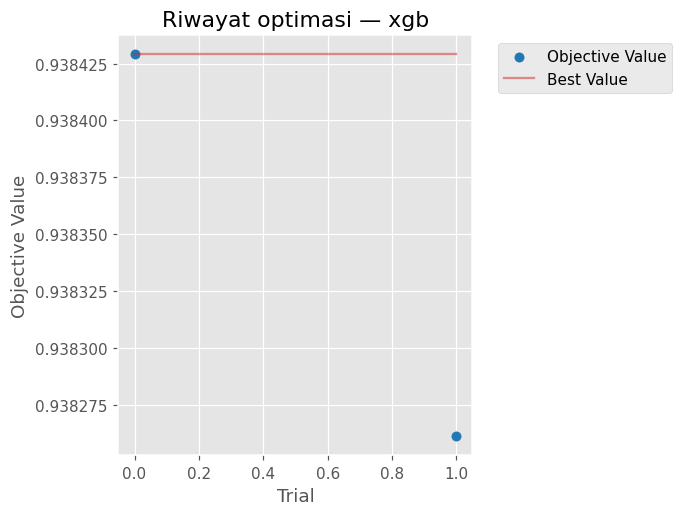

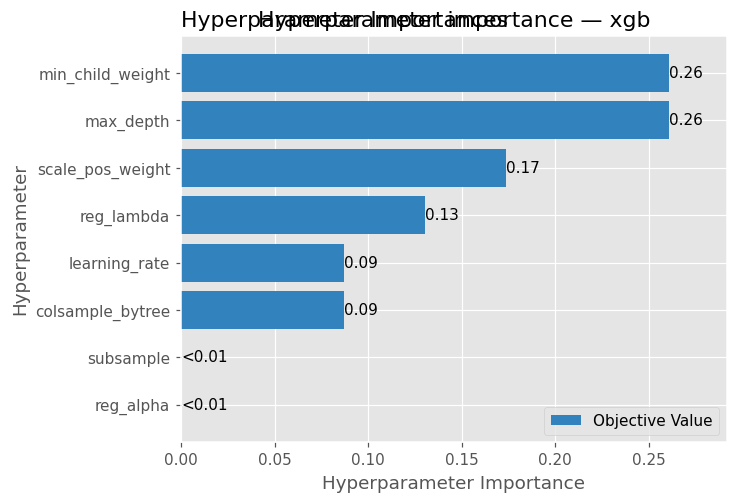

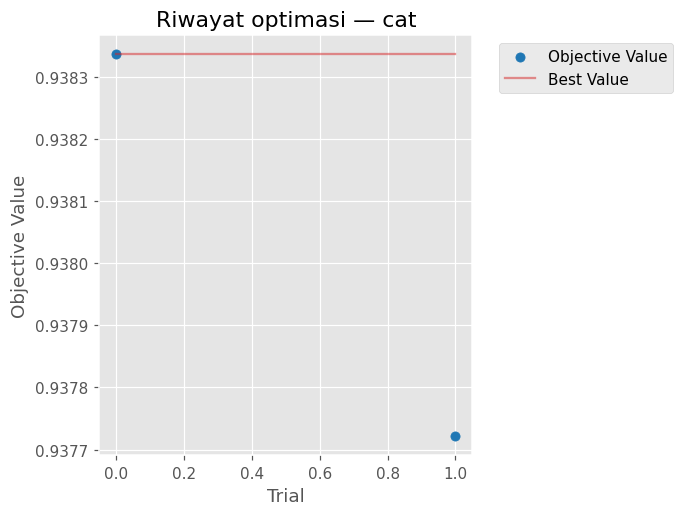

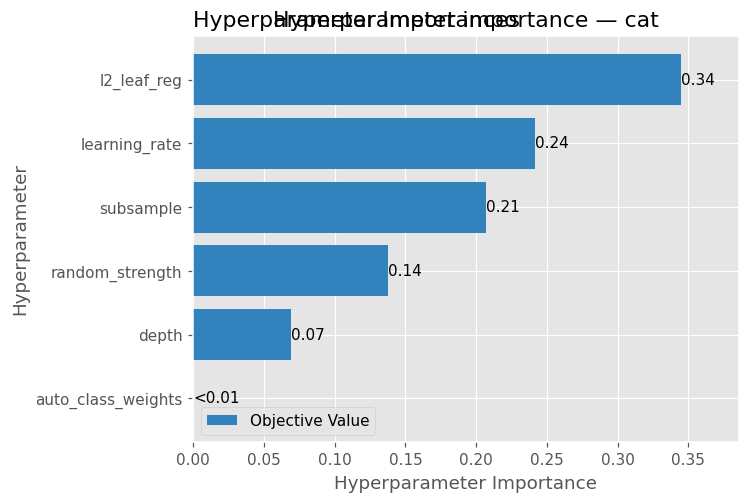

In [16]:
for study in (study_xgb, study_cat):
    plot_optimization_history(study).set_title(f"Riwayat optimasi — {study.study_name}")
    plot_param_importances(study).set_title(f"Hyperparameter importance — {study.study_name}")
plt.show()

##
<div style="background: linear-gradient(90deg, #1a1a2e, #16213e); border-left: 4px solid #e94560; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #f5a623; margin: 0 0 8px 0;">Training Final · Stratified 10-Fold</h2>
  <p style="color: #ffd6a5; margin: 0;">Parameter terbaik dilatih ulang pada 10 fold dengan early stopping. Prediksi <strong>out-of-fold (OOF)</strong> dikoreksi prior (bobot kelas) lalu menjadi dasar pemilihan bobot ensemble &amp; threshold — holdout tetap tidak tersentuh.</p>
</div>

In [17]:
best = {"xgb": study_xgb.best_params, "cat": study_cat.best_params}
oof_xgb, auc_xgb, it_xgb = cv_fit("xgb", best["xgb"], FEATS["xgb"], folds)
oof_cat, auc_cat, it_cat = cv_fit("cat", best["cat"], FEATS["cat"], folds)

# prior correction: bobot kelas positif efektif tiap model (lihat Strategi Menangani Imbalance)
PRIOR = {"xgb": best["xgb"]["scale_pos_weight"],
         "cat": {None: 1.0, "SqrtBalanced": POS_WEIGHT ** 0.5, "Balanced": POS_WEIGHT}[best["cat"]["auto_class_weights"]]}
oof_xgb, oof_cat = ev.prior_correct(oof_xgb, PRIOR["xgb"]), ev.prior_correct(oof_cat, PRIOR["cat"])

fold_auc = pd.DataFrame({"XGBoost": auc_xgb, "CatBoost": auc_cat}, index=pd.RangeIndex(1, N_FOLDS + 1, name="fold"))
print(fold_auc.agg(["mean", "std"]).round(5))
print(f"\nOOF AUC — XGBoost {roc_auc_score(y_train, oof_xgb):.5f} | CatBoost {roc_auc_score(y_train, oof_cat):.5f}")
print(f"Best iteration rata-rata — XGBoost {np.mean(it_xgb):.0f} | CatBoost {np.mean(it_cat):.0f}")
print(f"Prior scale — XGBoost {PRIOR['xgb']:.2f} | CatBoost {PRIOR['cat']:.2f}")
fold_auc.T.round(5)

      XGBoost  CatBoost
mean  0.93886   0.93861
std   0.00048   0.00084

OOF AUC — XGBoost 0.92266 | CatBoost 0.93841
Best iteration rata-rata — XGBoost 163 | CatBoost 83
Prior scale — XGBoost 1.62 | CatBoost 1.00


fold,1,2,3
XGBoost,0.93850,0.93941,0.93868
CatBoost,0.93778,0.93947,0.93858


##
<div style="background: linear-gradient(90deg, #2d0036, #4a0060); border-left: 4px solid #bf5af2; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #e0aaff; margin: 0 0 10px 0;">Weighted Soft Voting &amp; Threshold</h2>
  <ul style="color: #c77dff; margin: 0; padding-left: 20px;">
    <li>Ensemble: <strong>p = w · p<sub>XGB</sub> + (1 − w) · p<sub>CatBoost</sub></strong> (probabilitas setelah prior correction).</li>
    <li>Bobot <em>w</em> dicari grid 0–1 (step 0.01) dengan ROC-AUC OOF tertinggi.</li>
    <li>Threshold keputusan = titik F1 tertinggi pada kurva precision–recall OOF ensemble.</li>
  </ul>
</div>

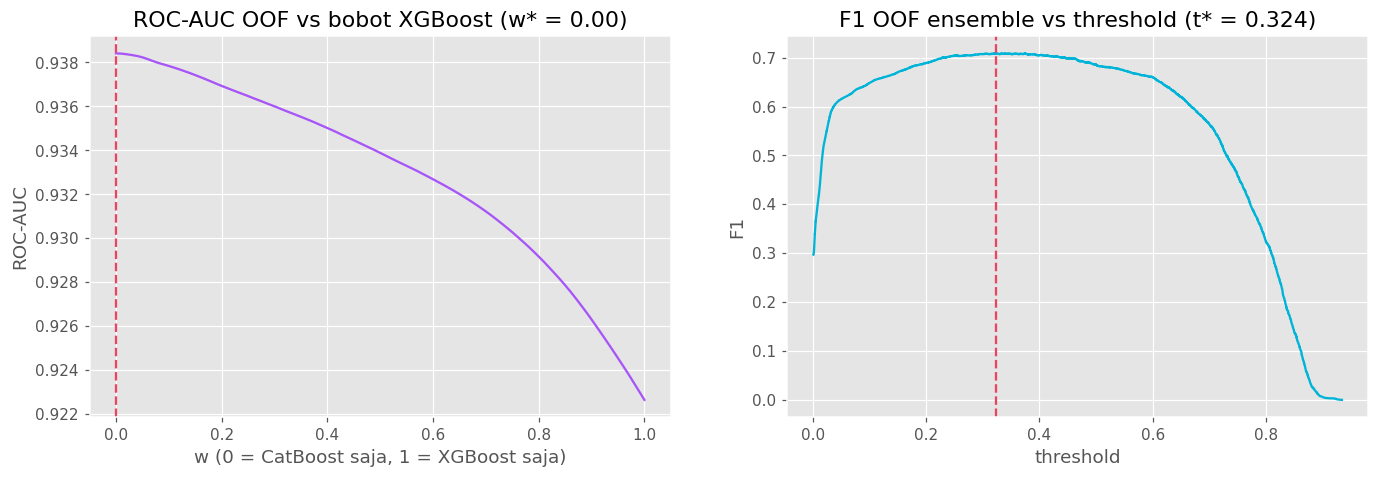

OOF AUC — ensemble 0.93841 | XGBoost saja 0.92266 | CatBoost saja 0.93841


In [18]:
def f1_threshold(y_true, p):
    """Threshold dengan F1 tertinggi + kurva (threshold, F1)."""
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
    return float(thr[f1.argmax()]), thr, f1


weights = np.linspace(0, 1, 101)
auc_w = [roc_auc_score(y_train, w * oof_xgb + (1 - w) * oof_cat) for w in weights]
W = float(weights[np.argmax(auc_w)])
oof_ens = W * oof_xgb + (1 - W) * oof_cat
THRESHOLD, thr, f1 = f1_threshold(y_train, oof_ens)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.5))
a1.plot(weights, auc_w, c="#a855f7")
a1.axvline(W, ls="--", c="#e94560")
a1.set(title=f"ROC-AUC OOF vs bobot XGBoost (w* = {W:.2f})", xlabel="w (0 = CatBoost saja, 1 = XGBoost saja)",
       ylabel="ROC-AUC")
a2.plot(thr, f1, c="#00b4d8")
a2.axvline(THRESHOLD, ls="--", c="#e94560")
a2.set(title=f"F1 OOF ensemble vs threshold (t* = {THRESHOLD:.3f})", xlabel="threshold", ylabel="F1")
plt.show()
print(f"OOF AUC — ensemble {max(auc_w):.5f} | XGBoost saja {auc_w[-1]:.5f} | CatBoost saja {auc_w[0]:.5f}")

##
<div style="background: linear-gradient(90deg, #10002b, #240046); border-left: 4px solid #c77dff; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #e0aaff; margin: 0 0 10px 0;">Refit (Seed Averaging) &amp; Evaluasi Holdout</h2>
  <ul style="color: #9d8cff; margin: 0; padding-left: 20px;">
    <li>Model final = <strong>3 seed per algoritma</strong>, dilatih ulang pada seluruh 80% train dengan iterasi = rata-rata best iteration 10-fold; probabilitas dirata-rata antar-seed lalu dikoreksi prior.</li>
    <li>Dievaluasi <strong>sekali</strong> di holdout 20% → skor ini adalah skor model yang di-serve FastAPI.</li>
    <li>Metrik label (accuracy, precision, recall, F1) memakai threshold F1-optimal OOF milik masing-masing model.</li>
    <li><strong>Brier score</strong> + kurva kalibrasi memeriksa apakah probabilitas sesuai frekuensi nyata.</li>
  </ul>
</div>

In [19]:
n_iter = {"xgb": int(np.mean(it_xgb)) + 1, "cat": int(np.mean(it_cat)) + 1}  # best iteration berbasis 0
final = {name: [make_model(name, best[name], FEATS[name], n=n_iter[name], early_stop=False, seed=SEED + i)
                .fit(X_train[FEATS[name]], y_train, verbose=False) for i in range(N_SEEDS)]
         for name in ("xgb", "cat")}


def proba(name, X_):
    """Rata-rata antar-seed -> prior correction."""
    return ev.prior_correct(np.mean([m.predict_proba(X_[FEATS[name]])[:, 1] for m in final[name]], axis=0), PRIOR[name])


p_test = {"XGBoost": proba("xgb", X_test), "CatBoost": proba("cat", X_test)}
p_test["Ensemble"] = W * p_test["XGBoost"] + (1 - W) * p_test["CatBoost"]
thresholds = {"XGBoost": f1_threshold(y_train, oof_xgb)[0], "CatBoost": f1_threshold(y_train, oof_cat)[0],
              "Ensemble": THRESHOLD}


def metrics(p, t):
    pred = (p >= t).astype(int)
    return {"ROC-AUC": roc_auc_score(y_test, p), "PR-AUC": average_precision_score(y_test, p),
            "Accuracy": accuracy_score(y_test, pred), "Precision": precision_score(y_test, pred),
            "Recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred),
            "Brier": brier_score_loss(y_test, p), "Threshold": t}


holdout = pd.DataFrame({k: metrics(p, thresholds[k]) for k, p in p_test.items()}).T
holdout.round(5)

,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1,Brier,Threshold
XGBoost,0.94498,0.76197,0.87717,0.59910,0.89293,0.71708,0.08214,0.22114
CatBoost,0.94430,0.75997,0.88717,0.63226,0.84321,0.72265,0.06958,0.32409
Ensemble,0.94430,0.75997,0.88717,0.63226,0.84321,0.72265,0.06958,0.32409


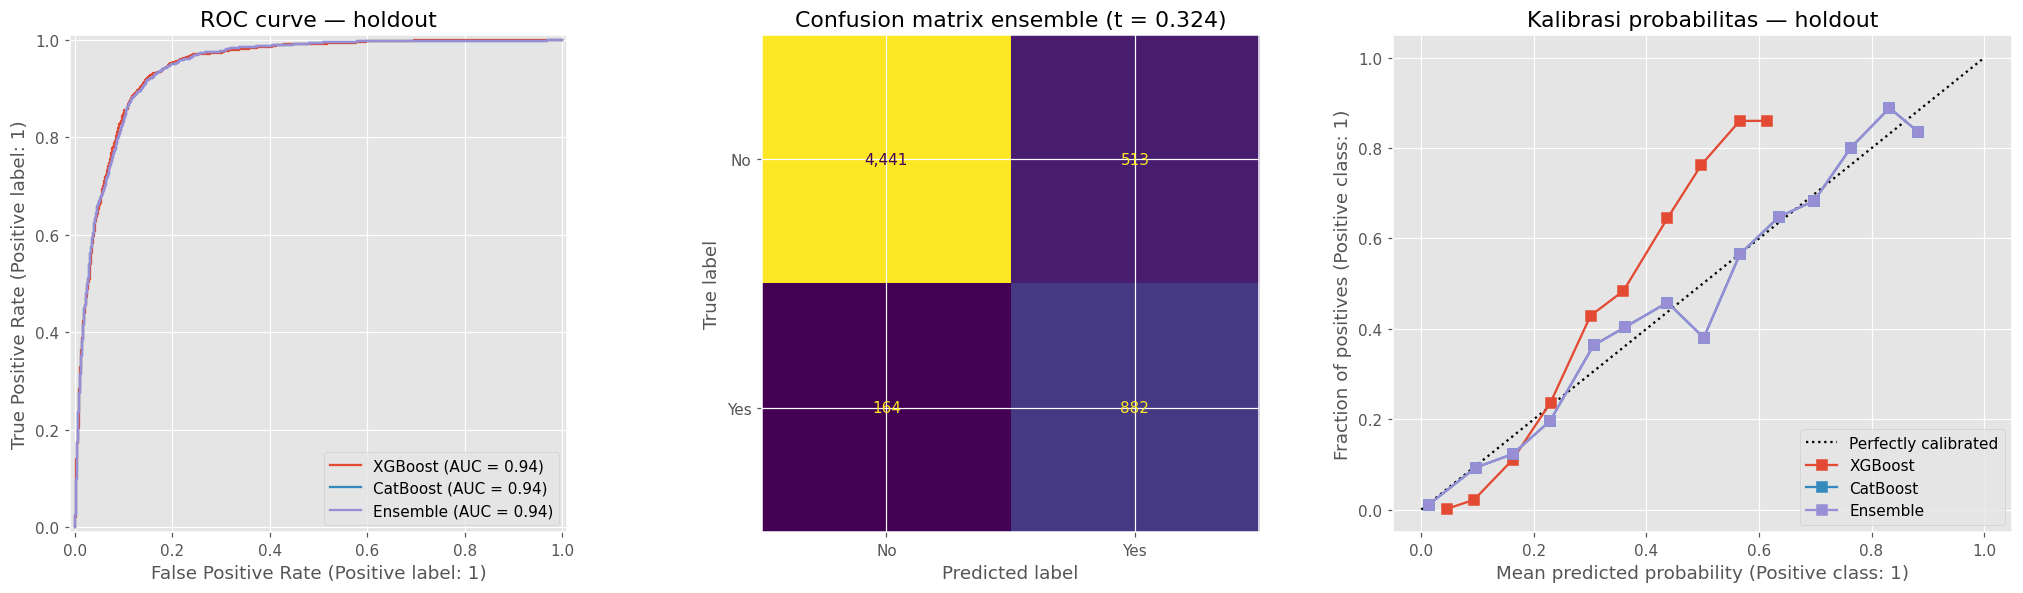

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for name, p in p_test.items():
    RocCurveDisplay.from_predictions(y_test, p, name=name, ax=axes[0])
    CalibrationDisplay.from_predictions(y_test, p, n_bins=15, name=name, ax=axes[2])
ConfusionMatrixDisplay.from_predictions(y_test, (p_test["Ensemble"] >= THRESHOLD).astype(int),
                                        display_labels=["No", "Yes"], ax=axes[1], colorbar=False, values_format=",")
axes[0].set_title("ROC curve — holdout")
axes[1].set_title(f"Confusion matrix ensemble (t = {THRESHOLD:.3f})")
axes[2].set_title("Kalibrasi probabilitas — holdout")
plt.tight_layout()
plt.show()

##
<div style="background: linear-gradient(90deg, #03071e, #370617); border-left: 4px solid #f48c06; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #ffd60a; margin: 0 0 10px 0;">Bootstrap CI</h2>
  <ul style="color: #ffb703; margin: 0; padding-left: 20px;">
    <li>Holdout di-resample dengan pengembalian (2000×) → CI 95% ROC-AUC tiap model.</li>
    <li>Selisih ensemble − model tunggal terbaik dihitung pada resample yang sama (berpasangan); P(Δ ≤ 0) ≈ p-value satu sisi bahwa ensemble tidak lebih baik.</li>
  </ul>
</div>

In [21]:
rng = np.random.default_rng(SEED)
yt = y_test.to_numpy()
boot = []
for _ in range(N_BOOT):
    i = rng.integers(0, len(yt), len(yt))
    boot.append({k: roc_auc_score(yt[i], p[i]) for k, p in p_test.items()})
boot = pd.DataFrame(boot)
best_single = holdout.loc[["XGBoost", "CatBoost"], "ROC-AUC"].idxmax()
diff = boot["Ensemble"] - boot[best_single]
print(f"Ensemble − {best_single}: ΔAUC {diff.mean():.5f} | CI95 [{diff.quantile(0.025):.5f}, {diff.quantile(0.975):.5f}] "
      f"| P(Δ ≤ 0) = {(diff <= 0).mean():.3f}")
boot.quantile([0.025, 0.975]).T.set_axis(["CI95 bawah", "CI95 atas"], axis=1).assign(**{"ROC-AUC": holdout["ROC-AUC"]}).round(5)

Ensemble − XGBoost: ΔAUC -0.00073 | CI95 [-0.00238, 0.00089] | P(Δ ≤ 0) = 0.815


,CI95 bawah,CI95 atas,ROC-AUC
XGBoost,0.93815,0.95138,0.94498
CatBoost,0.93789,0.95067,0.94430
Ensemble,0.93789,0.95067,0.94430


##
<div style="background: linear-gradient(90deg, #012a4a, #013a63); border-left: 4px solid #48cae4; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #90e0ef; margin: 0 0 8px 0;">Analisis per Segmen</h2>
  <p style="color: #ade8f4; margin: 0;">Performa ensemble per <strong>Gender</strong> &amp; <strong>City_Type</strong> di holdout — memeriksa konsistensi dan potensi bias antar-kelompok.</p>
</div>

In [22]:
seg = df.loc[idx_test].assign(y=y_test, p=p_test["Ensemble"])
rows = []
for col in ("Gender", "City_Type"):
    for val, g in seg.groupby(col):
        pred = (g["p"] >= THRESHOLD).astype(int)
        rows.append({"segmen": f"{col} = {val}", "n": len(g), "% Yes": g["y"].mean(), "ROC-AUC": roc_auc_score(g["y"], g["p"]),
                     "Precision": precision_score(g["y"], pred), "Recall": recall_score(g["y"], pred),
                     "F1": f1_score(g["y"], pred)})
pd.DataFrame(rows).set_index("segmen").round(4)

,n,% Yes,ROC-AUC,Precision,Recall,F1
segmen,,,,,,
Gender = Female,2666,0.1789,0.9459,0.6379,0.8532,0.7300
Gender = Male,3277,0.1700,0.9433,0.6250,0.8348,0.7148
Gender = Other,57,0.2105,0.9296,0.7692,0.8333,0.8000
City_Type = Rural,1127,0.1970,0.9491,0.6689,0.8919,0.7645
City_Type = Suburban,2264,0.1930,0.9356,0.6370,0.8352,0.7228
City_Type = Urban,2609,0.1483,0.9503,0.6065,0.8243,0.6988


##
<div style="background: linear-gradient(90deg, #1b1b2f, #2d2b55); border-left: 4px solid #a855f7; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #d8b4fe; margin: 0 0 10px 0;">Interpretasi Model · SHAP</h2>
  <ul style="color: #c4b5fd; margin: 0; padding-left: 20px;">
    <li>SHAP native (XGBoost <code>pred_contribs</code>, CatBoost <code>ShapValues</code>) pada 10,000 sampel holdout, dari model seed pertama — tanpa dependency tambahan.</li>
    <li>Beeswarm: posisi horizontal = kontribusi ke log-odds; warna = nilai fitur (merah tinggi, biru rendah).</li>
    <li>Bar mean |SHAP| (dinormalisasi) membandingkan fitur terpenting kedua model.</li>
  </ul>
</div>

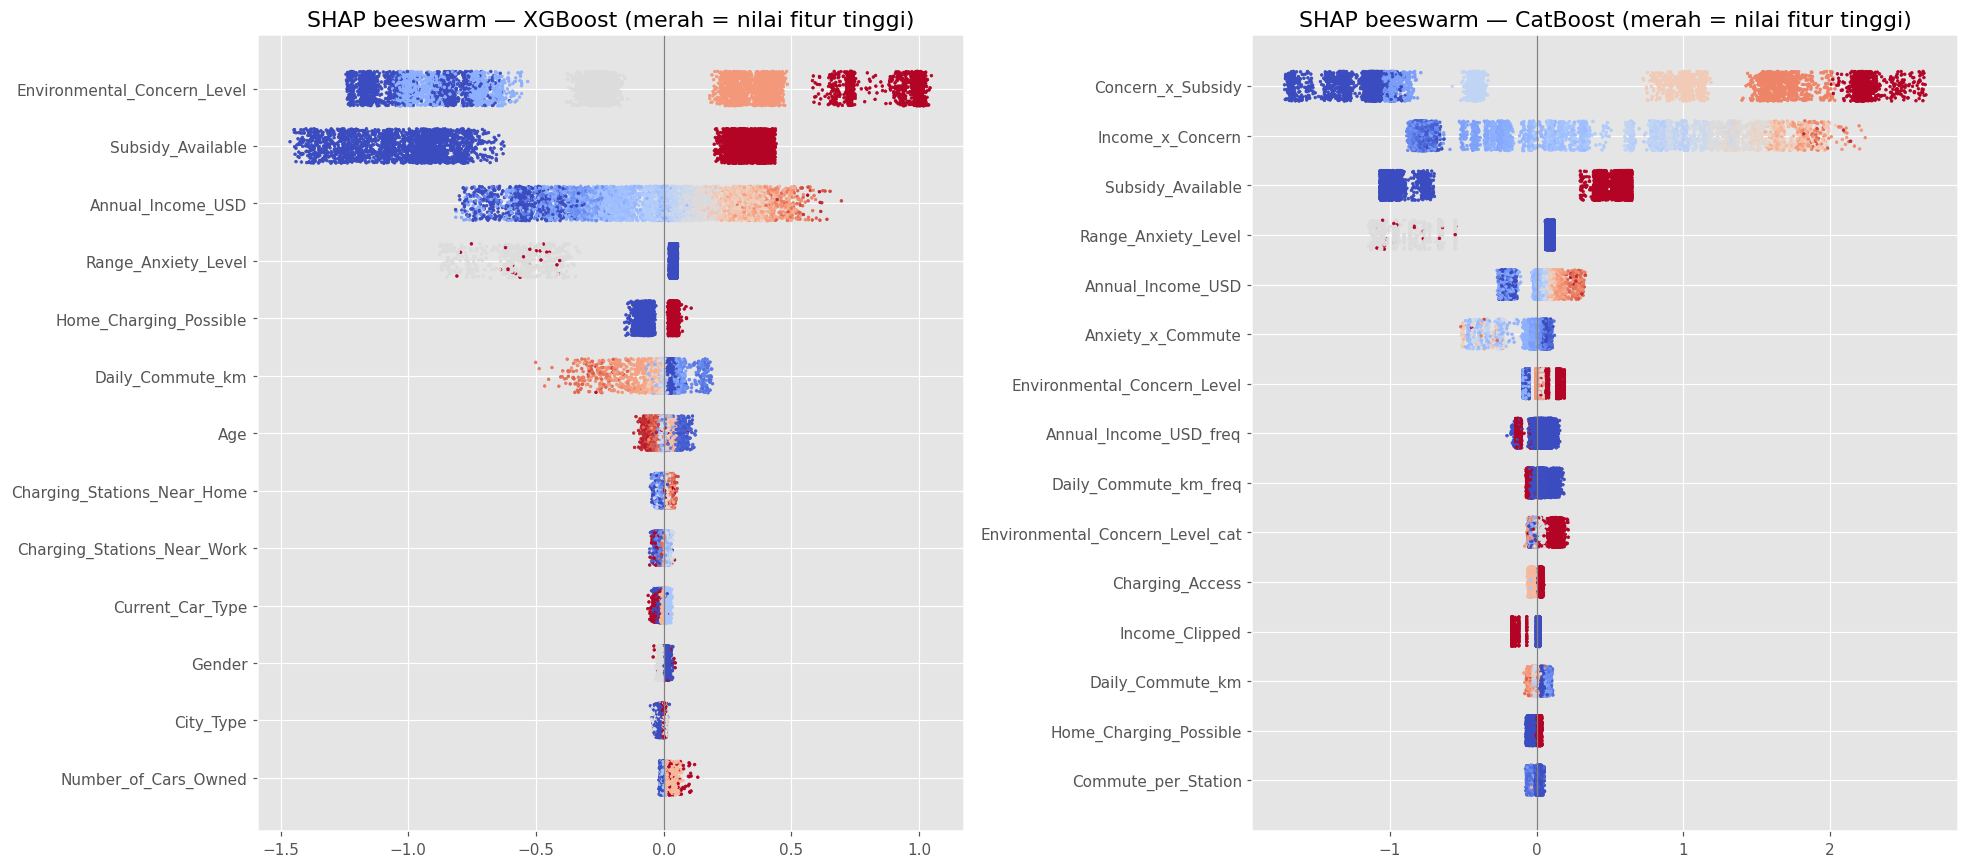

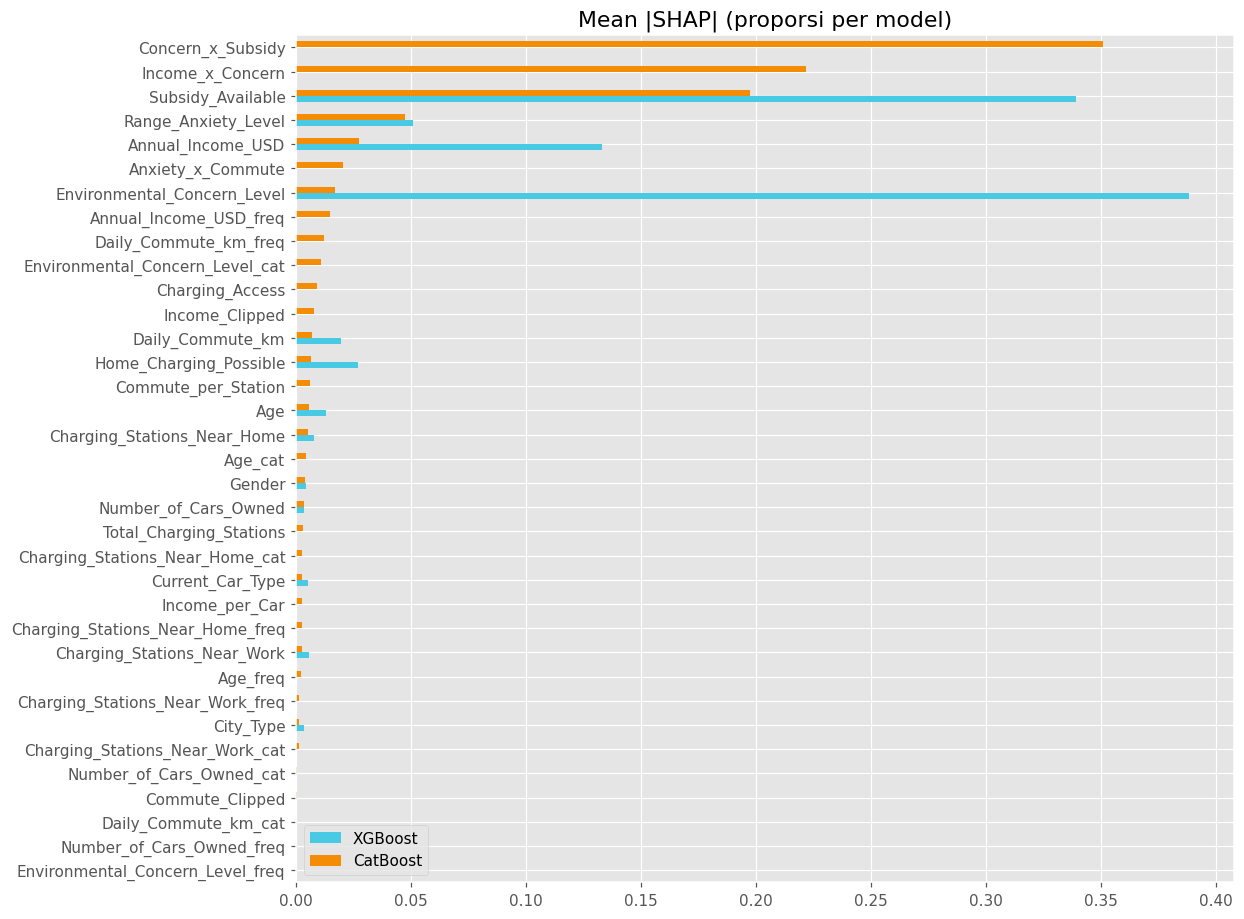

In [23]:
sample = X_test.sample(min(10_000, len(X_test)), random_state=SEED)
shap_vals = {
    "XGBoost": final["xgb"][0].get_booster().predict(DMatrix(sample[FEATS["xgb"]], enable_categorical=True),
                                                     pred_contribs=True)[:, :-1],
    "CatBoost": final["cat"][0].get_feature_importance(Pool(sample[FEATS["cat"]], cat_features=cat_cols(FEATS["cat"])),
                                                       type="ShapValues")[:, :-1],
}
feats_of = {"XGBoost": FEATS["xgb"], "CatBoost": FEATS["cat"]}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, (name, sv) in zip(axes, shap_vals.items()):
    top = np.argsort(np.abs(sv).mean(0))[-15:]
    for row, j in enumerate(top):
        v = sample[feats_of[name][j]]
        v = v.cat.codes if v.dtype.name == "category" else pd.to_numeric(v)  # salinan _cat berisi angka dalam string
        ax.scatter(sv[:, j], row + np.random.default_rng(j).uniform(-0.3, 0.3, len(v)),
                   c=(v - v.min()) / (v.max() - v.min() + 1e-12), cmap="coolwarm", s=3)
    ax.set_yticks(range(len(top)), [feats_of[name][j] for j in top])
    ax.axvline(0, c="gray", lw=0.8)
    ax.set_title(f"SHAP beeswarm — {name} (merah = nilai fitur tinggi)")
plt.tight_layout()
plt.show()

mean_abs = pd.DataFrame({name: pd.Series(np.abs(sv).mean(0), index=feats_of[name]) for name, sv in shap_vals.items()})
(mean_abs / mean_abs.sum()).sort_values("CatBoost").plot.barh(figsize=(11, 10), color=["#48cae4", "#f48c06"],
                                                              title="Mean |SHAP| (proporsi per model)")
plt.show()

##
<div style="background: linear-gradient(90deg, #0d1b2a, #1b263b); border-left: 4px solid #00b4d8; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #90e0ef; margin: 0 0 10px 0;">Simpan Artefak &amp; Uji Inferensi (Simulasi FastAPI)</h2>
  <ul style="color: #ade8f4; margin: 0; padding-left: 20px;">
    <li><strong>xgb_{0,1,2}.ubj</strong> · <strong>cat_{0,1,2}.cbm</strong> · <strong>ensemble.json</strong> (fitur per model, bobot, threshold, prior scale, parameter, metrik, versi library, tabel frekuensi) · <strong>optuna.db</strong></li>
    <li><strong>sample_predictions.csv</strong>: 1,000 baris holdout mentah + probabilitas yang diharapkan — fixture regresi untuk memverifikasi artefak di environment lain (lokal / FastAPI).</li>
    <li>Artefak di-load ulang dengan <code>ev_web.model.load()</code> — fungsi yang sama yang akan dipakai FastAPI — lalu prediksinya harus identik; satu record dict mensimulasikan payload <code>/predict</code>; kategori tak dikenal ditolak.</li>
  </ul>
</div>

In [24]:
for name, ext in (("xgb", "ubj"), ("cat", "cbm")):
    for i, m in enumerate(final[name]):
        m.save_model(str(MODEL_DIR / f"{name}_{i}.{ext}"))
meta = {
    "features": FEATS,
    "weight_xgb": W,
    "threshold": THRESHOLD,
    "prior_scale": PRIOR,
    "n_seeds": N_SEEDS,
    "params": best,
    "n_iter": n_iter,
    "cv_auc_oof": {"xgb": roc_auc_score(y_train, oof_xgb), "cat": roc_auc_score(y_train, oof_cat), "ensemble": max(auc_w)},
    "holdout": holdout.to_dict(orient="index"),
    "versions": {"python": sys.version.split()[0], "xgboost": xgboost.__version__, "catboost": catboost.__version__,
                 "sklearn": sklearn.__version__, "pandas": pd.__version__},
    "trained_on": f"kaggle, {N_GPUS} GPU" if ON_KAGGLE else f"lokal, {N_GPUS} GPU",
    "commit": COMMIT,
    "created_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "freq": {c: {repr(float(k)): int(n) for k, n in s.items()} for c, s in FREQ.items()},
}
(MODEL_DIR / "ensemble.json").write_text(json.dumps(meta, indent=1))
df.loc[idx_test[:1000], ev.FEATURES].assign(p_expected=p_test["Ensemble"][:1000]).to_csv(
    MODEL_DIR / "sample_predictions.csv", index=False)
sorted(f"{p.name} ({p.stat().st_size / 1e6:.2f} MB)" for p in MODEL_DIR.iterdir())

['cat_0.cbm (0.05 MB)',
 'cat_1.cbm (0.08 MB)',
 'ensemble.json (0.12 MB)',
 'optuna.db (0.11 MB)',
 'sample_predictions.csv (0.08 MB)',
 'xgb_0.ubj (0.51 MB)',
 'xgb_1.ubj (0.52 MB)']

In [25]:
models = ev.load(MODEL_DIR)
p_reload = ev.predict_proba(models, df.loc[idx_test])
assert np.allclose(p_reload, p_test["Ensemble"]), "Prediksi setelah reload berbeda!"
print("Round-trip artefak OK: prediksi reload == prediksi in-memory")

payload = {  # 1 calon pembeli, format sama dengan request JSON ke FastAPI
    "Age": 35, "Annual_Income_USD": 85000.0, "Daily_Commute_km": 30.0, "Number_of_Cars_Owned": 1,
    "Charging_Stations_Near_Home": 5, "Charging_Stations_Near_Work": 8, "Environmental_Concern_Level": 4.0,
    "Gender": "Female", "City_Type": "Urban", "Current_Car_Type": "Sedan",
    "Home_Charging_Possible": "Yes", "Subsidy_Available": "Yes", "Range_Anxiety_Level": "Low",
}
p = ev.predict_proba(models, pd.DataFrame([payload]))[0]
print(f"P(Will_Buy_EV = Yes) = {p:.3f} -> prediksi: {'Yes' if p >= models['threshold'] else 'No'}")

try:
    ev.predict_proba(models, pd.DataFrame([{**payload, "City_Type": "Mars"}]))
except ValueError as e:
    print(f"Validasi input bekerja -> {e}")

Round-trip artefak OK: prediksi reload == prediksi in-memory
P(Will_Buy_EV = Yes) = 0.536 -> prediksi: Yes
Validasi input bekerja -> Nilai kosong/tidak dikenal di kolom: ['City_Type']


##
<div style="background: linear-gradient(90deg, #1a1a2e, #16213e); border-left: 4px solid #e94560; border-radius: 8px; padding: 18px 24px;">
  <h2 style="color: #f5a623; margin: 0 0 10px 0;">Kesimpulan &amp; Langkah Berikutnya</h2>
  <ul style="color: #ffd6a5; margin: 0; padding-left: 20px;">
    <li>Ringkasan angka final dicetak sel di bawah, langsung dari hasil run (bukan diketik manual).</li>
    <li>Artefak di <code>models/</code> siap dipakai FastAPI lewat <code>ev_web.model.load()</code> + <code>predict_proba()</code>.</li>
    <li>Fase berikutnya: endpoint <code>/predict</code> dengan schema Pydantic (Literal enum untuk kategori, batas numerik).</li>
  </ul>
</div>

In [26]:
print(f"Fitur dipakai   : XGBoost {len(FEATS['xgb'])}, CatBoost {len(FEATS['cat'])} (kandidat {len(CANDIDATES['xgb'])} / {len(CANDIDATES['cat'])})")
print(f"Bobot ensemble  : w_XGB = {W:.2f}, w_CatBoost = {1 - W:.2f} | threshold = {THRESHOLD:.3f}")
print(f"OOF AUC {N_FOLDS}-fold : " + " | ".join(f"{k} {v:.5f}" for k, v in meta["cv_auc_oof"].items()))
print("Holdout ROC-AUC : " + " | ".join(f"{k} {v:.5f}" for k, v in holdout["ROC-AUC"].items()))

Fitur dipakai   : XGBoost 13, CatBoost 35 (kandidat 29 / 35)
Bobot ensemble  : w_XGB = 0.00, w_CatBoost = 1.00 | threshold = 0.324
OOF AUC 3-fold : xgb 0.92266 | cat 0.93841 | ensemble 0.93841
Holdout ROC-AUC : XGBoost 0.94498 | CatBoost 0.94430 | Ensemble 0.94430
